Solving HW 1

In [132]:
# ============================================================
# ORBIT
# Homework 1
# Main Script
# ============================================================

using LinearAlgebra
using Plots

# ============================================================
# Include Modules
# ============================================================

include("Satellite.jl")
include("Rotations.jl")
include("Time.jl")
include("SolveKepler.jl")
include("coordinates.jl")
include("Propagation.jl")
include("Results.jl")
include("Plotting.jl")

# ============================================================
# Constants
# ============================================================

GM = 398600.44                  # km^3/s^2
ωE = 2π / 86164.0               # rad/s


7.292123516990375e-5

In [130]:
# ============================================================
# Satellite Definitions
# ============================================================

gps = Satellite(
    "GPS",
    26500.0,
    0.01,
    deg2rad(55.0),
    deg2rad(0.0),
    deg2rad(0.0),
    deg2rad(0.0)
)

gnss = Satellite(
    "GNSS (Old)",
    42164.0,
    0.0,
    deg2rad(63.0),
    deg2rad(0.0),
    deg2rad(0.0),
    deg2rad(0.0)
)

galileo = Satellite(
    "Galileo",
    29994.0,
    0.0,
    deg2rad(56.0),
    deg2rad(0.0),
    deg2rad(0.0),
    deg2rad(0.0)
)

champ = Satellite(
    "CHAMP",
    6838.0,
    0.004,
    deg2rad(87.0),
    deg2rad(0.0),
    deg2rad(0.0),
    deg2rad(0.0)
)

molniya = Satellite(
    "Molniya",
    26554.0,
    0.7,
    deg2rad(65.0),
    deg2rad(245.0),
    deg2rad(270.0),
    deg2rad(0.0)
)

# ============================================================
# Store Satellites
# ============================================================

satellites = [
    gps,
    gnss,
    galileo,
    champ,
    molniya
]


5-element Vector{Satellite}:
 Satellite("GPS", 26500.0, 0.01, 0.9599310885968813, 0.0, 0.0, 0.0)
 Satellite("GNSS (Old)", 42164.0, 0.0, 1.0995574287564276, 0.0, 0.0, 0.0)
 Satellite("Galileo", 29994.0, 0.0, 0.9773843811168246, 0.0, 0.0, 0.0)
 Satellite("CHAMP", 6838.0, 0.004, 1.5184364492350666, 0.0, 0.0, 0.0)
 Satellite("Molniya", 26554.0, 0.7, 1.1344640137963142, 4.276056667386108, 4.71238898038469, 0.0)

Satellite : GPS
Number of Time Steps : 8587

Initial ECI Position (km)
[26235.0, 0.0, 0.0]

Initial ECEF Position (km)
[26235.0, 0.0, 0.0]

Initial Latitude  (deg) : 0.0
Initial Longitude (deg) : 0.0



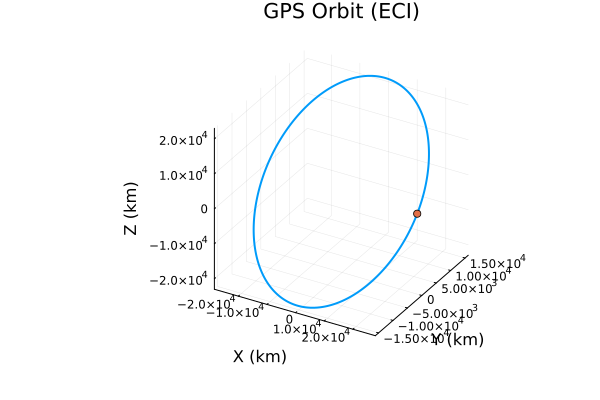

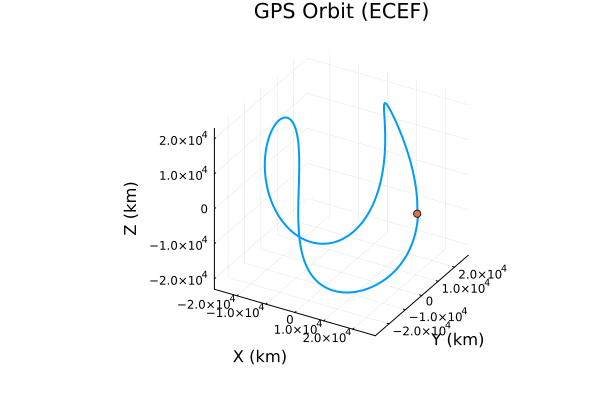

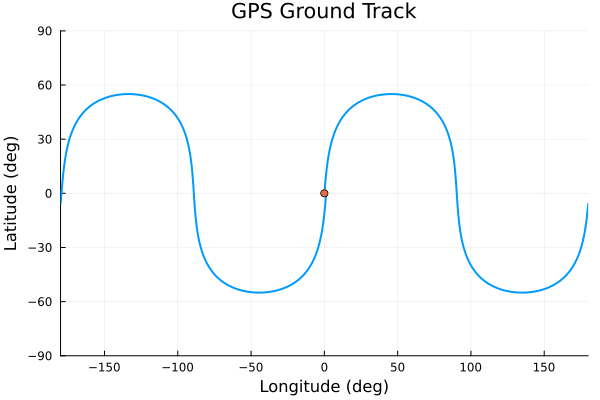

Satellite : GNSS (Old)
Number of Time Steps : 17233

Initial ECI Position (km)
[42164.0, 0.0, 0.0]

Initial ECEF Position (km)
[42164.0, 0.0, 0.0]

Initial Latitude  (deg) : 0.0
Initial Longitude (deg) : 0.0



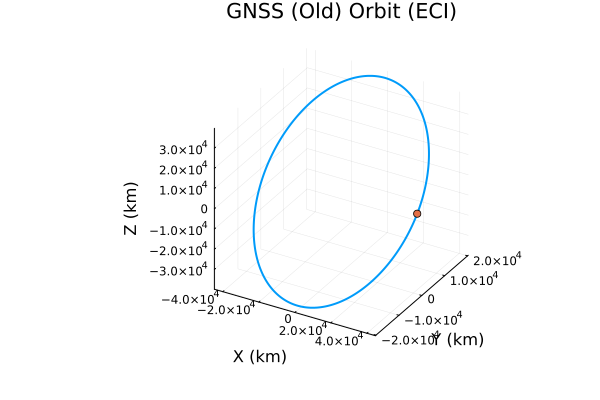

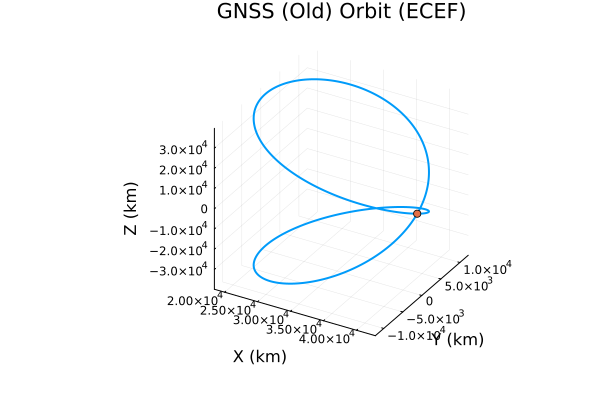

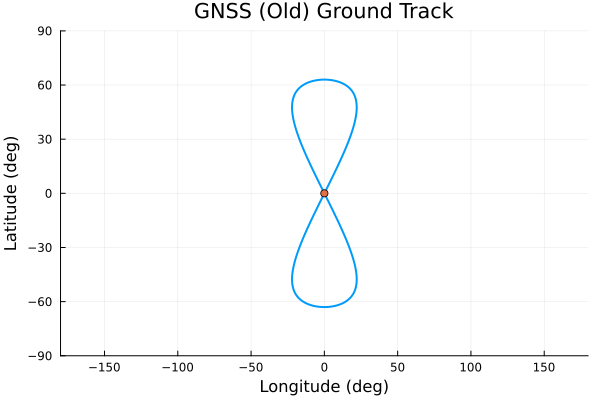

Satellite : Galileo
Number of Time Steps : 10340

Initial ECI Position (km)
[29994.0, 0.0, 0.0]

Initial ECEF Position (km)
[29994.0, 0.0, 0.0]

Initial Latitude  (deg) : 0.0
Initial Longitude (deg) : 0.0



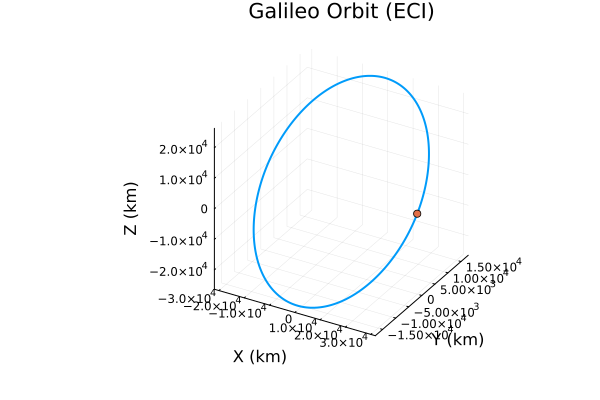

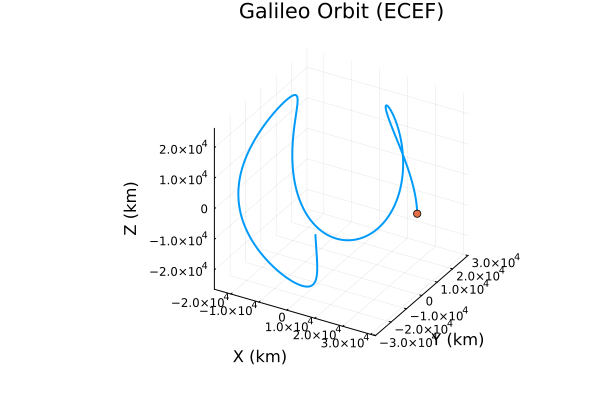

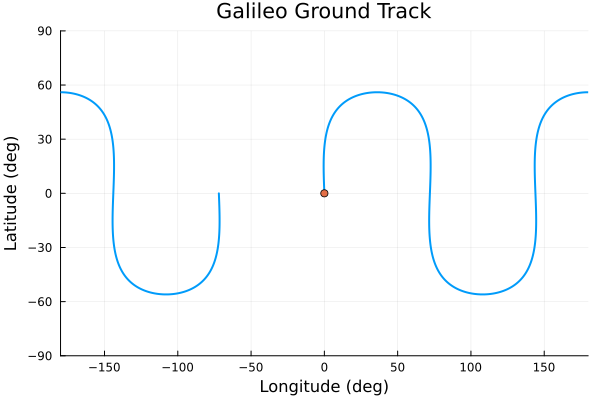

Satellite : CHAMP
Number of Time Steps : 1126

Initial ECI Position (km)
[6810.648, 0.0, 0.0]

Initial ECEF Position (km)
[6810.648, 0.0, 0.0]

Initial Latitude  (deg) : 0.0
Initial Longitude (deg) : 0.0



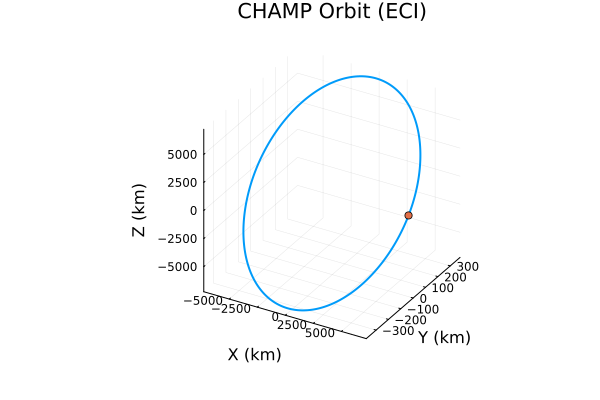

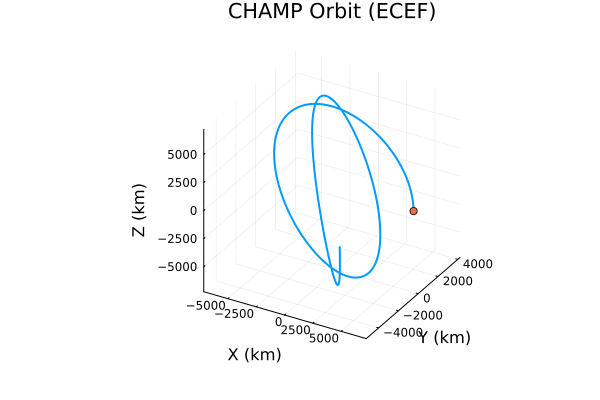

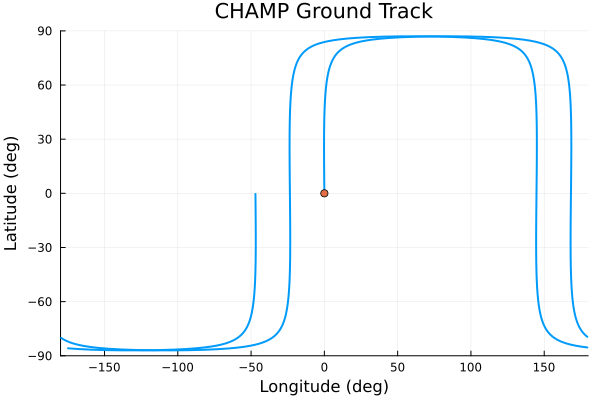

Satellite : Molniya
Number of Time Steps : 8613

Initial ECI Position (km)
[-3051.2316213872023, 1422.8126718575459, -7219.829093091362]

Initial ECEF Position (km)
[-3051.2316213872023, 1422.8126718575459, -7219.829093091362]

Initial Latitude  (deg) : -64.99999999999997
Initial Longitude (deg) : 155.0



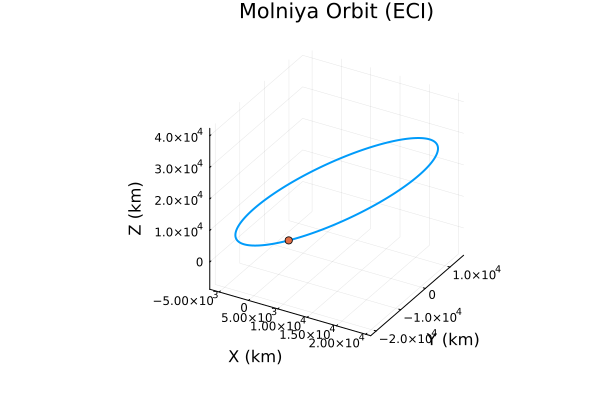

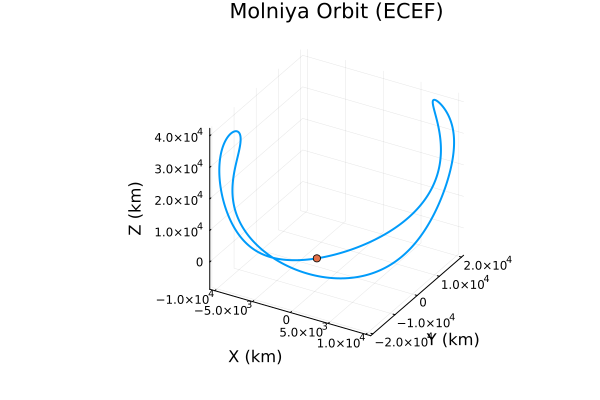

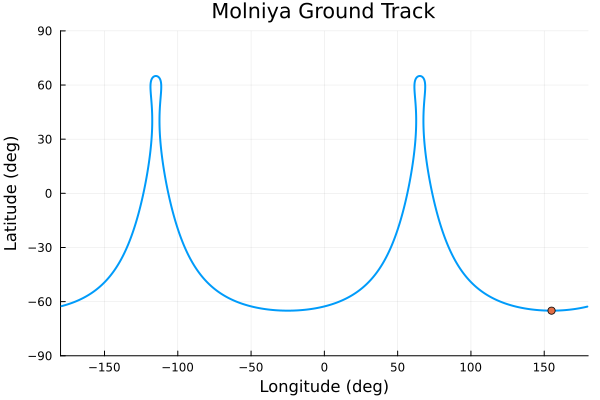

In [133]:


# ============================================================
# Propagate and Plot
# ============================================================

for sat in satellites

    println("====================================================")
    println("Satellite : ", sat.name)
    println("====================================================")

    result = propagate_kepler(
        sat,
        GM,
        ωE
    )

    println("Number of Time Steps : ", length(result.time))
    println()

    println("Initial ECI Position (km)")
    println(result.positions_eci[:,1])
    println()

    println("Initial ECEF Position (km)")
    println(result.positions_ecef[:,1])
    println()

    println("Initial Latitude  (deg) : ", result.latitudes[1])
    println("Initial Longitude (deg) : ", result.longitudes[1])
    println()

    # --------------------------------------------------------
    # Plot Orbit in ECI
    # --------------------------------------------------------

    plot_orbit(
        result.positions_eci;
        title = "$(sat.name) Orbit (ECI)"
    )

    # --------------------------------------------------------
    # Plot Orbit in ECEF
    # --------------------------------------------------------

    plot_orbit(
        result.positions_ecef;
        title = "$(sat.name) Orbit (ECEF)"
    )

    # --------------------------------------------------------
    # Plot Ground Track
    # --------------------------------------------------------

    plot_groundtrack(
        result.latitudes,
        result.longitudes;
        title = "$(sat.name) Ground Track"
    )

end